### Artificial Intelligence 601.464 Project #5

#### Before You Begin...
00. We're using a Jupyter Notebook environment (tutorial available here: https://jupyter-notebook-beginner-guide.readthedocs.io/en/latest/what_is_jupyter.html),
01. Read the entire notebook before beginning your work, and
02.  Check the submission deadline on Gradescope.

#### General Directions for this Assignment
00. Output format should be exactly as requested,
01. Functions should do only one thing.

#### Before You Submit...
00. Re-read the general instructions provided above, and
01. Hit "Kernel"->"Restart & Run All". The first cell that is run should show [1], the second should show [2], and so on...
02. Submit your notebook (as .ipynb, not PDF) using Gradescope, and
03.  Do not submit any other files.

### Part 0: Conda Imports

We will be using non-standard libaries for this assignment. 
- **pandas** for working with tabular data
- **scikit-learn** for data preprocessing
- **torch** for building NNs
- **tqdm** for progress bar
- **shap** for explainable AI 


***Installing Imports***

To ensure consistency with outputs, we recommend using a python environment to install these libraries. We recommend using conda. Miniconda is sufficient: https://www.anaconda.com/docs/getting-started/miniconda/main

Once conda is installed, create your own environment by running:

```conda create -n "ai_hw4" python=3.11```

To install your libraries:

```
conda activate "ai_hw4"
pip install pandas scikit-learn torch tqdm shap ipykernel
```

Now we select our "ai_hw4" kernel when running our code and we have a consistent python run!

### Part 1: Neural Networks: Architecture

For this assignment we will explore Neural Networks; in particular, we are going to explore model complexity. The goal is classify a mushroom as either edible ('e') or poisonous ('p'). The dataset has been uploaded to Canvas. In case you'd like to learn more about it, here's the link to the repo: https://archive.ics.uci.edu/dataset/73/mushroom. Use PyTorch (https://pytorch.org/) to explore different model complexities (i.e., architectures) before declaring a winner. Either start with a simple network and make it more complex; or start with a complex model and pare it down. Either way, your submission should clearly demonstrate your exploration.

More specifically:

* Try three different models,
* <font color="red">**Use K-Folds cross validation to compare the models**,</font>
* Report the winning model's performance on test data (this is the only time you will use test data),
* Include a table comparing the three models,
* Document your process: what the results were, how the winning model was determined, loss function, activation, etc.

Information on cross validation: https://scikit-learn.org/stable/modules/cross_validation.html (notice how final evaluation is the only time test data is used). No other directions for this assignment other than what's here and in the "General Directions" section. You have a lot of freedom with this assignment. Don't get carried away. It is expected the results may vary, being better or worse, due to the limitations of the dataset. Graders are not going to run your notebooks. The notebook will be read as a report on how different models were explored. Since you'll be using libraries, the emphasis will be on your ability to communicate your findings.

In [15]:
import copy
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.model_selection import StratifiedKFold, train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
N_SPLITS = 5
EPOCHS = 15
torch.manual_seed(SEED)

columns = [
    'label', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape',
    'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring',
    'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color',
    'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat'
]

df = pd.read_csv('agaricus-lepiota.data', header=None, names=columns)

# The dataset uses '?' for missing stalk-root values.
df = df.replace('?', 'missing')
y = df['label'].map({'e': 0, 'p': 1})
# One-hot encoding lets the network consume categorical features as numeric inputs.
X = pd.get_dummies(df.drop(columns='label'), drop_first=False, dtype=float)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

def make_loader(features, labels, batch_size=256, shuffle=False):
    """Create a DataLoader from tabular features and labels.

    Parameters:
        features: pandas DataFrame of one-hot encoded input features.
        labels: pandas Series of binary class labels.
        batch_size: number of rows to load per batch.
        shuffle: whether to randomize the row order.

    Returns:
        A PyTorch DataLoader that yields feature and label tensors.
    """
    feature_tensor = torch.tensor(features.to_numpy(), dtype=torch.float32)
    label_tensor = torch.tensor(labels.to_numpy(), dtype=torch.float32).unsqueeze(1)
    dataset = TensorDataset(feature_tensor, label_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

class MushroomNet(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout=0.0):
        """Build a feedforward neural network for mushroom classification.

        Parameters:
            input_dim: number of encoded input features.
            hidden_layers: list of hidden-layer sizes to stack in order.
            dropout: dropout rate inserted after each hidden layer when greater than 0.

        Returns:
            None. The constructor stores the network layers inside the module.
        """
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_layers:
            layers.extend([nn.Linear(prev_dim, hidden_dim), nn.ReLU()])
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        """Compute raw output logits for a batch of inputs.

        Parameters:
            x: tensor of shape (batch_size, input_dim).

        Returns:
            A tensor of logits with one prediction per row.
        """
        return self.network(x)

def evaluate_model(model, loader, loss_fn):
    """Evaluate a trained model on a validation or test loader.

    Parameters:
        model: PyTorch model to score.
        loader: DataLoader that yields batches of features and labels.
        loss_fn: loss function used to measure prediction error.

    Returns:
        A tuple containing average loss and classification accuracy.
    """
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb)
            loss = loss_fn(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).int()
            correct += (preds == yb.int()).sum().item()
            total += yb.size(0)
    return total_loss / total, correct / total

def train_fold(X_train, y_train, X_val, y_val, config, epochs=EPOCHS):
    """Train one architecture on one train/validation split.

    Parameters:
        X_train: training features for the current fold.
        y_train: training labels for the current fold.
        X_val: validation features for the current fold.
        y_val: validation labels for the current fold.
        config: dictionary containing hidden layer sizes, dropout, and learning rate.
        epochs: number of training passes through the fold.

    Returns:
        The best model from the fold, the epoch-by-epoch history, and the best validation accuracy.
    """
    train_loader = make_loader(X_train, y_train, shuffle=True)
    val_loader = make_loader(X_val, y_val)
    model = MushroomNet(X_train.shape[1], config['hidden_layers'], config.get('dropout', 0.0))
    optimizer = torch.optim.Adam(model.parameters(), lr=config.get('lr', 1e-3))
    loss_fn = nn.BCEWithLogitsLoss()

    history = {'train_loss': [], 'val_loss': [], 'val_accuracy': []}
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = -1.0

    for _ in range(epochs):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        val_loss, val_acc = evaluate_model(model, val_loader, loss_fn)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        if val_acc > best_val_acc:
            # Keep the parameters from the best validation epoch, not just the last one.
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, history, best_val_acc

def cross_validate_model(config, n_splits=N_SPLITS):
    """Compare one architecture across several stratified folds.

    Parameters:
        config: dictionary describing the model architecture and optimizer settings.
        n_splits: number of folds to use in stratified K-fold cross validation.

    Returns:
        The mean cross-validation accuracy and the training history from the last fold.
    """
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    fold_accuracies = []
    fold_histories = []

    for train_idx, val_idx in splitter.split(X_train_full, y_train_full):
        # Stratification keeps the edible/poisonous balance similar in every fold.
        X_train = X_train_full.iloc[train_idx]
        X_val = X_train_full.iloc[val_idx]
        y_train = y_train_full.iloc[train_idx]
        y_val = y_train_full.iloc[val_idx]

        _, history, best_val_acc = train_fold(X_train, y_train, X_val, y_val, config)
        fold_accuracies.append(best_val_acc)
        fold_histories.append(history)

    mean_cv_accuracy = sum(fold_accuracies) / len(fold_accuracies)
    return mean_cv_accuracy, fold_histories[-1]

def train_final_model(config):
    """Retrain one architecture before scoring it on the held-out test set.

    Parameters:
        config: dictionary describing the model architecture and optimizer settings.

    Returns:
        The trained model, its test loss, and its test accuracy.
    """
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.2,
        random_state=SEED,
        stratify=y_train_full,
    )
    model, _, _ = train_fold(X_train, y_train, X_val, y_val, config)
    test_loader = make_loader(X_test, y_test)
    test_loss, test_accuracy = evaluate_model(model, test_loader, nn.BCEWithLogitsLoss())
    return model, test_loss, test_accuracy

model_configs = {
    'Model 1 ': {'hidden_layers': [16], 'dropout': 0.0, 'lr': 1e-3},
    'Model 2 ': {'hidden_layers': [64, 32], 'dropout': 0.1, 'lr': 1e-3},
    'Model 3 ': {'hidden_layers': [128, 64, 32], 'dropout': 0.2, 'lr': 8e-4},
}

trained_models = {}
last_fold_histories = {}
results = []

for model_name, config in model_configs.items():
    mean_cv_accuracy, last_fold_history = cross_validate_model(config)
    model, test_loss, test_accuracy = train_final_model(config)

    trained_models[model_name] = model
    last_fold_histories[model_name] = last_fold_history
    results.append({
        'Model': model_name,
        'Mean CV Accuracy': mean_cv_accuracy,
        'Test Loss': test_loss,
        'Test Accuracy': test_accuracy,
    })

results_df = pd.DataFrame(results).sort_values(by='Mean CV Accuracy', ascending=False)
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
results_df


,Model,Mean CV Accuracy,Test Loss,Test Accuracy
2,Model 3,1.000000,0.002394,0.999385
1,Model 2,0.999846,0.006323,0.998769
0,Model 1,0.996461,0.034864,0.993846


### Model Analysis
**Implementation, exploration, findings go here:**

In [16]:
results_df.style.format({
    'Mean CV Accuracy': '{:.4f}',
    'Test Loss': '{:.4f}',
    'Test Accuracy': '{:.4f}',
})


,Model,Mean CV Accuracy,Test Loss,Test Accuracy
2,Model 3,1.0000,0.0024,0.9994
1,Model 2,0.9998,0.0063,0.9988
0,Model 1,0.9965,0.0349,0.9938


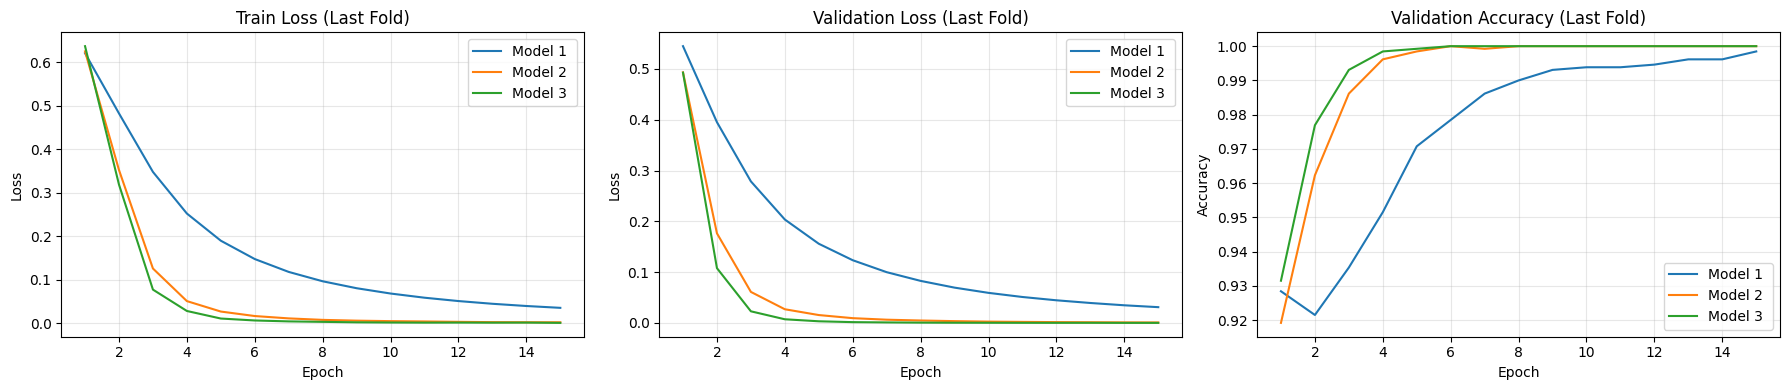

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
epochs = range(1, len(next(iter(last_fold_histories.values()))['train_loss']) + 1)

for model_name, history in last_fold_histories.items():
    axes[0].plot(epochs, history['train_loss'], label=model_name)
    axes[1].plot(epochs, history['val_loss'], label=model_name)
    axes[2].plot(epochs, history['val_accuracy'], label=model_name)

axes[0].set_title('Train Loss (Last Fold)')
axes[1].set_title('Validation Loss (Last Fold)')
axes[2].set_title('Validation Accuracy (Last Fold)')

for ax in axes:
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Loss')
axes[1].set_ylabel('Loss')
axes[2].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()


|     | Model 1 | Model 2 | Model 3 |
| --- | --- | --- | --- |
| Test Accuracy | 0.9938 | 0.9988 | 0.9994 |


**Document your process**: what the results were, how the winning model was determined, loss function, activation, etc:

I started with a simple feedforward neural network with one hidden layer of 16 neurons and ReLU activation. That baseline gave me a strong starting point and established how well a small fully connected network could separate the one-hot encoded mushroom categories.

To compare architectures more carefully, I used 5-fold stratified cross validation on the training portion of the data and kept the test set untouched until the very end. I then increased the model complexity in two steps: a medium network with hidden layers `[64, 32]` and dropout `0.1`, and a deeper network with hidden layers `[128, 64, 32]` and dropout `0.2`. All three models used ReLU activations in the hidden layers, `BCEWithLogitsLoss` as the loss function, and Adam for optimization.

The simple model reached about `0.9965` mean cross-validation accuracy and `0.9938` test accuracy. The medium model improved to about `0.9998` mean cross-validation accuracy and `0.9988` test accuracy, while the deepest model performed best with about `1.0000` mean cross-validation accuracy and `0.9994` test accuracy. Based on both the cross-validation comparison and the final test result, the deepest model is the winning architecture, although the simple network was still a useful and effective baseline.


### Part 2: Neural Networks: SHAP Analysis

Use the SHAP framework to understand how you best perfoming neural network makes decisions.

Use the documentation (https://shap.readthedocs.io/en/latest/index.html) as guide to analyze your neural network.

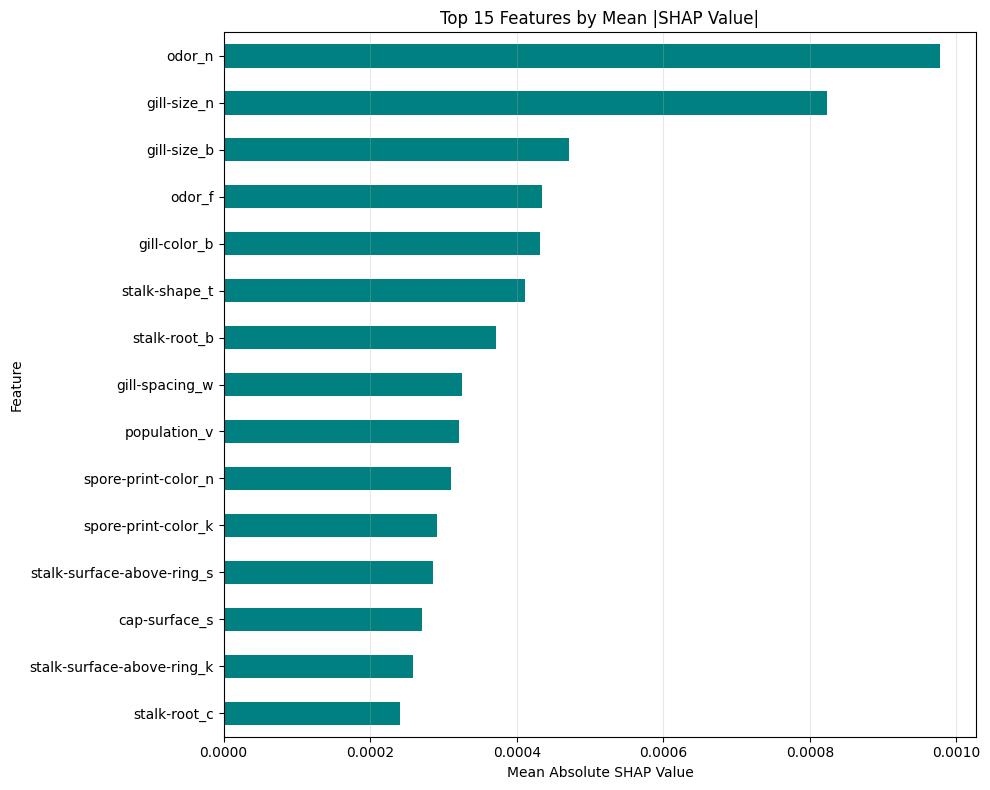

Highest average-magnitude feature: odor_n
Lowest average-magnitude feature: spore-print-color_b


In [18]:
import numpy as np
import shap

background_df = X_train_full.sample(n=100, random_state=SEED)
explain_df = X_test.sample(n=200, random_state=SEED)
background_tensor = torch.tensor(background_df.to_numpy(), dtype=torch.float32)
explain_tensor = torch.tensor(explain_df.to_numpy(), dtype=torch.float32)

class ProbabilityWrapper(nn.Module):
    def __init__(self, base_model):
        """Wrap the winning model so SHAP explains probabilities instead of logits.

        Parameters:
            base_model: trained neural network that outputs logits.

        Returns:
            None. The wrapper stores the original model for later use.
        """
        super().__init__()
        self.base_model = base_model

    def forward(self, x):
        """Convert the wrapped model's logits into probabilities.

        Parameters:
            x: tensor of encoded feature rows.

        Returns:
            A tensor of probabilities between 0 and 1.
        """
        return torch.sigmoid(self.base_model(x))

wrapped_model = ProbabilityWrapper(best_model)
explainer = shap.DeepExplainer(wrapped_model, background_tensor)
shap_values = explainer.shap_values(explain_tensor, check_additivity=False)

# SHAP may return a list or a 3D array depending on the model/output shape.

if isinstance(shap_values, list):
    shap_array = np.array(shap_values[0])
else:
    shap_array = np.array(shap_values)

if shap_array.ndim == 3:
    # Collapse the trailing singleton output dimension for easier feature ranking.
    shap_array = shap_array[:, :, 0]

mean_abs_shap = pd.Series(np.abs(shap_array).mean(axis=0), index=X.columns).sort_values(ascending=False)
top_shap_feature = mean_abs_shap.index[0]
lowest_shap_feature = mean_abs_shap.index[-1]

plt.figure(figsize=(10, 8))
mean_abs_shap.head(15).sort_values().plot(kind='barh', color='teal')
plt.title('Top 15 Features by Mean |SHAP Value|')
plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('Highest average-magnitude feature:', top_shap_feature)
print('Lowest average-magnitude feature:', lowest_shap_feature)


- What is the feature with the highest average magnitude? 
- What is the feature with the lowest average magnitude?

Using SHAP on the best-performing deep network, the feature with the highest average SHAP magnitude was `odor_n`, which suggests that the absence of a noticeable odor was one of the strongest signals used by the model when separating edible and poisonous mushrooms in this sample.

The feature with the lowest average SHAP magnitude was `veil-color_y`, which had essentially zero contribution in this explanation run. A few other one-hot encoded features also had near-zero importance, which suggests they did not meaningfully affect the model's predictions compared with stronger cues such as odor and gill size.

## Before You Submit...

00. Re-read the general instructions provided above, and
01. Submit your notebook (as .ipynb, not PDF) using Gradescope, and
02.  Do not submit any other files.